# Tutorial for Data

이 Notebook에는 참가자 분들께서 kspace, image data를 보다 쉽게 분석하실 수 있도록 간단한 시각화 예제를 첨부하였습니다.

## Setup

아래 코드를 실행하기 전, 필요한 module을 import합니다.

In [2]:
# Set up the environment for running a Python script that uses OpenCV and other libraries
!apt update
!apt install -y libgl1

# Install necessary Python packages
%pip install numpy matplotlib h5py opencv-python

'apt'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.
'apt'��(��) ���� �Ǵ� �ܺ� ����, ������ �� �ִ� ���α׷�, �Ǵ�
��ġ ������ �ƴմϴ�.


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import h5py
import cv2

## K-space data

kspace data를 담고 있는 h5 file은 아래와 같이 `kspace`, `mask`의 2가지 key를 갖습니다.
- `kspace`: kspace data. (shape: `(slices, coils, height, width)`)
- `mask`: kspace data를 undersampling하기 위한 mask. (shape: `(width, )`)

In [4]:
in_dir = "../Data/train/kspace/brain_acc4_1.h5"
kspace_f = h5py.File(in_dir)
kspace_f.keys()

in_dir_8 = "../Data/train/kspace/brain_acc8_1.h5"
kspace_f_8 = h5py.File(in_dir_8)
kspace_f_8.keys()

<KeysViewHDF5 ['kspace', 'mask']>

In [5]:
kspace = kspace_f['kspace']
mask = kspace_f['mask']
print(kspace.shape, mask.shape)

kspace_8 = kspace_f_8['kspace']
mask_8 = kspace_f_8['mask']
print(kspace_8.shape, mask_8.shape)

(16, 16, 768, 396) (396,)
(16, 16, 768, 396) (396,)


In [6]:
# kspace 4와 8 비교하기
print(mask[:])

[0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0.
 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0. 0. 1. 0. 0.

이제 kspace data를 시각화 해보겠습니다.

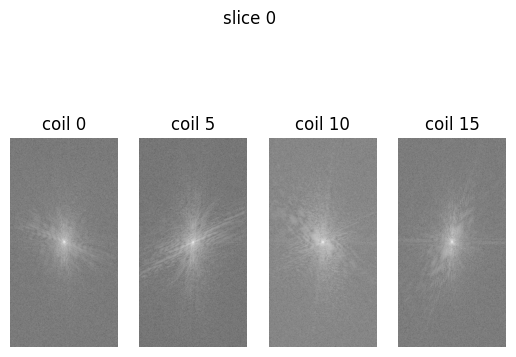

In [24]:
slice_len = kspace.shape[0]
for slice_idx in range(0, slice_len, 100):
    # convert kspace slice to real image
    kspace_slice = kspace[slice_idx]
    kspace_slice = np.log(np.abs(kspace_slice) + 1e-9)

    plt.figure()
    plt.suptitle(f'slice {slice_idx}')
    coil_len = kspace_slice.shape[0]
    for i, coil_idx in enumerate(range(0, coil_len, 5)):
        ax = plt.subplot(1, coil_len // 5 + 1, i + 1)
        plt.title(f'coil {coil_idx}')
        ax.imshow(kspace_slice[coil_idx], cmap='gray')
        plt.axis('off')  # Remove axes for a cleaner look

    plt.show()

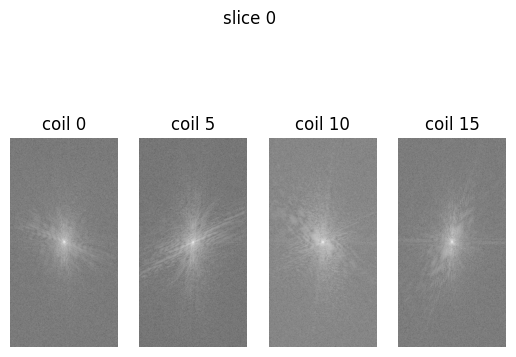

In [25]:
slice_len = kspace_8.shape[0]
for slice_idx in range(0, slice_len, 100):
    # convert kspace slice to real image
    kspace_slice = kspace[slice_idx]
    kspace_slice = np.log(np.abs(kspace_slice) + 1e-9)

    plt.figure()
    plt.suptitle(f'slice {slice_idx}')
    coil_len = kspace_slice.shape[0]
    for i, coil_idx in enumerate(range(0, coil_len, 5)):
        ax = plt.subplot(1, coil_len // 5 + 1, i + 1)
        plt.title(f'coil {coil_idx}')
        ax.imshow(kspace_slice[coil_idx], cmap='gray')
        plt.axis('off')  # Remove axes for a cleaner look

    plt.show()

위에서 확인하실 수 있듯, 본 challenge에서 다루는 data는 *multi-coil* data입니다. \
그러므로 하나의 slice에 대하여 서로 다른 coil로 얻어진 kspace data가 존재합니다. \
이들에 각각 inverse fourier transform을 취한 뒤, RSS(*root sum squared*) 연산을 취해 하나의 reconstruction image를 얻는 것입니다.

In [5]:
kspace_f.close()

## Image data (brain)

image data를 담고 있는 h5 file은 아래와 같이 `image_grappa`, `image_input`, `image_label`의 3가지 key를 갖습니다.
- `image_grappa`: _GRAPPA method_*를 사용하여 reconstruct한 image
- `image_input`: undersampled kspace data로부터 얻은 **aliased** image
- `image_label`: fully-sampled kspace data로부터 얻은 **aliasing free** image

각 파일에 대해, 세 이미지의 shape는 모두 `(slices, height, width)` 로 동일합니다. \
(*GRAPPA method에 관해서는 본 Challenge의 youtube channel에 설명 영상이 업로드되어 있습니다.)

In [10]:
in_dir = "../Data/train/image/brain_acc4_2.h5"
image_f = h5py.File(in_dir)
image_f.keys()

in_dir_8 = "../Data/leaderboard/acc4/image/brain_test1.h5"
image_f_8 = h5py.File(in_dir_8)
image_f_8.keys()

<KeysViewHDF5 ['image_grappa', 'image_input', 'image_label']>

In [11]:
image_grappa = image_f['image_grappa']
image_input = image_f['image_input']
image_label = image_f['image_label']
print(image_grappa.shape, image_input.shape, image_label.shape)

image_grappa_8 = image_f_8['image_grappa']
image_input_8 = image_f_8['image_input']
image_label_8 = image_f_8['image_label']
print(image_grappa_8.shape, image_input_8.shape, image_label_8.shape)

(16, 384, 384) (16, 384, 384) (16, 384, 384)
(16, 384, 384) (16, 384, 384) (16, 384, 384)


이제 image data를 시각화 해보겠습니다.

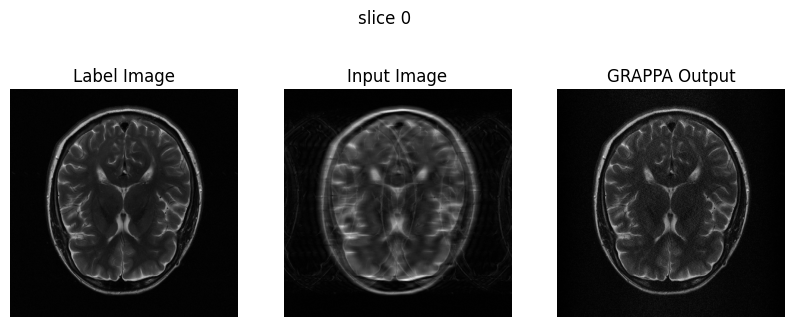

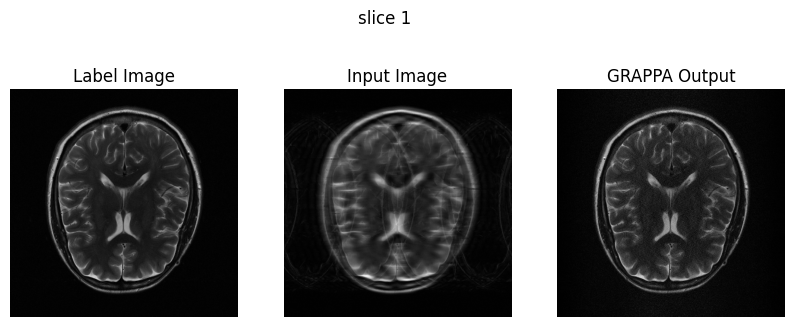

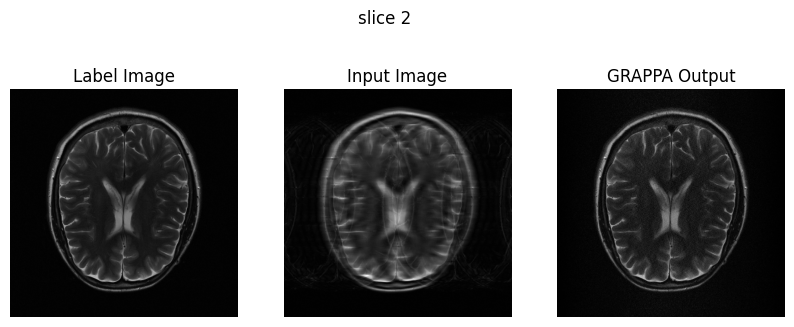

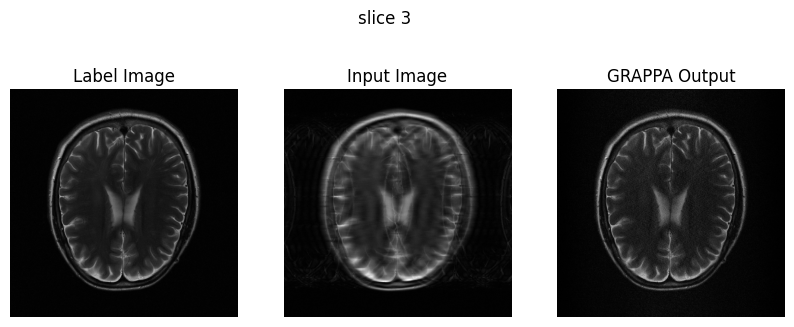

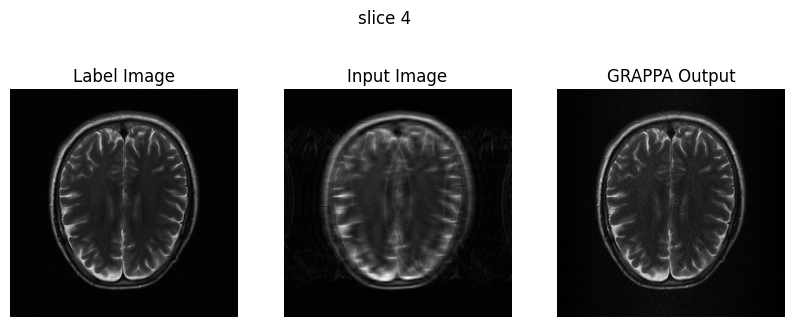

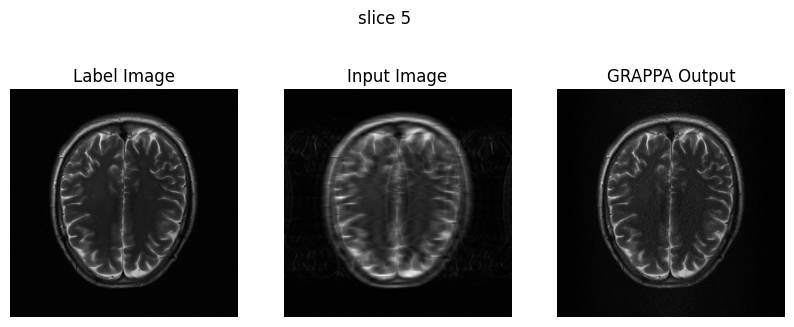

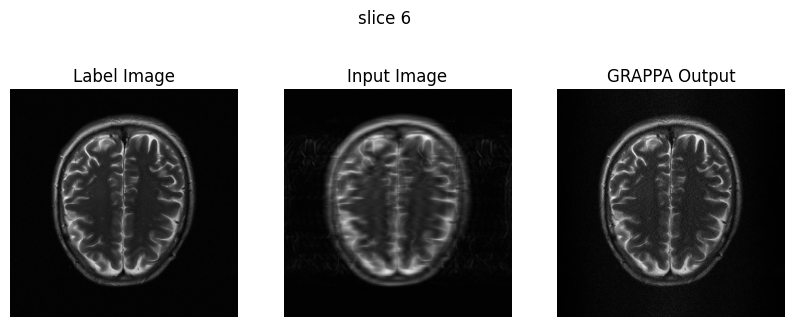

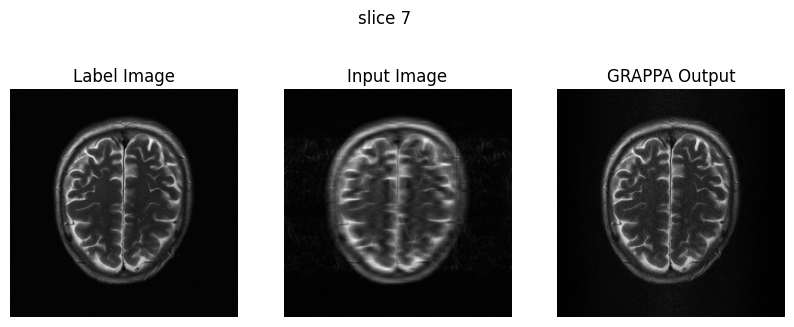

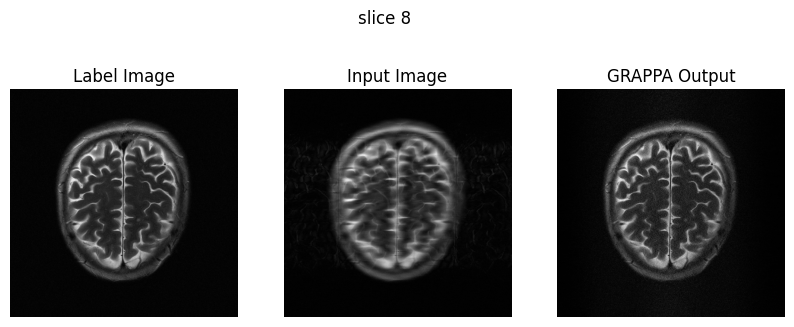

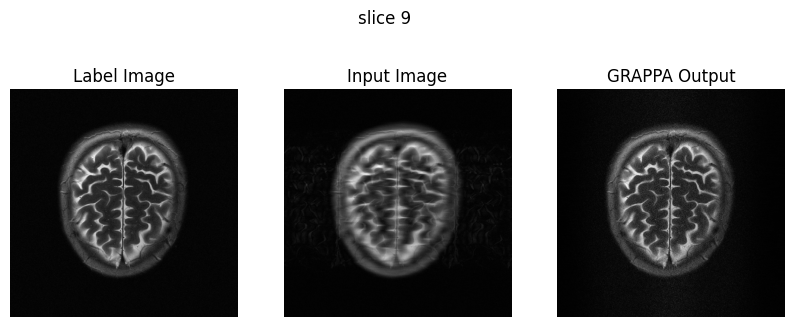

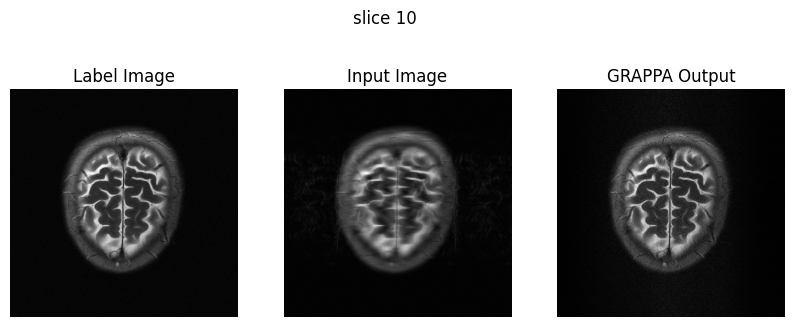

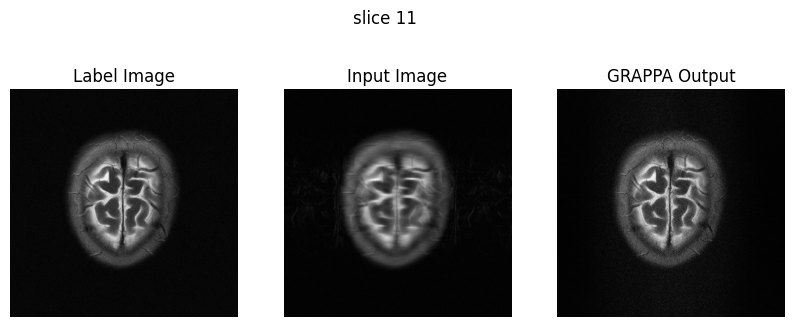

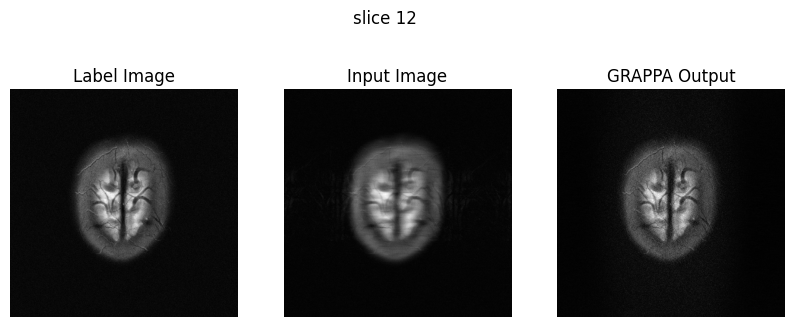

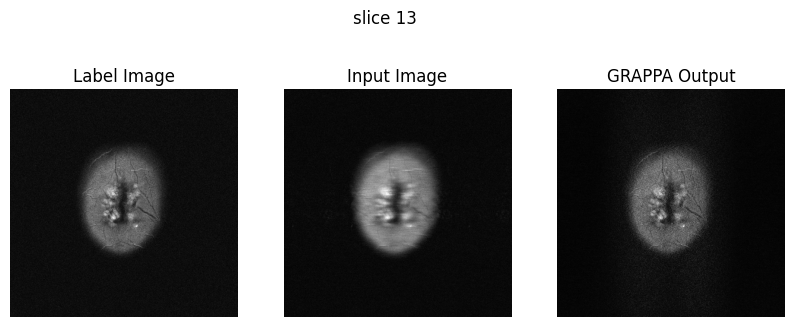

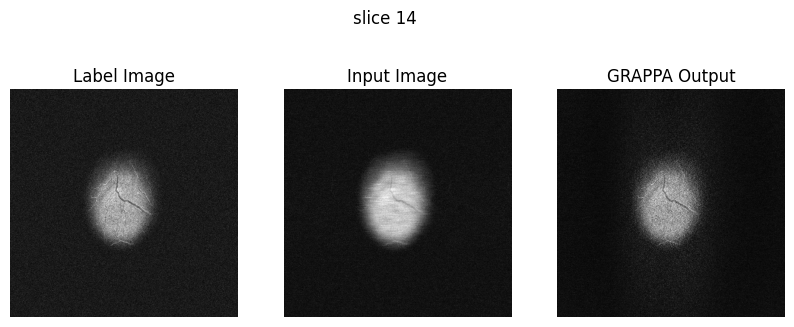

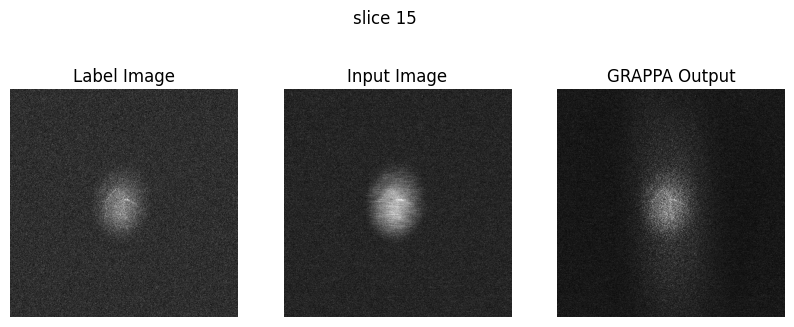

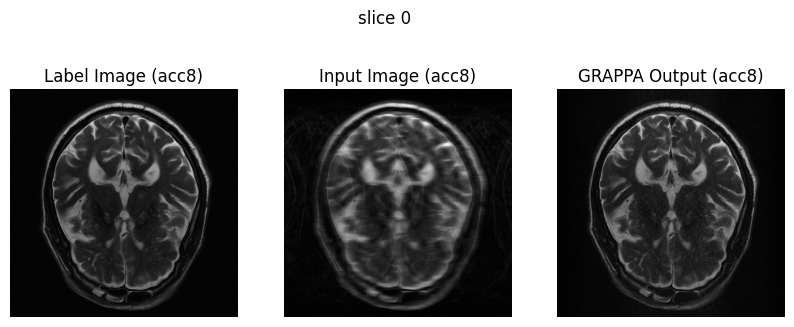

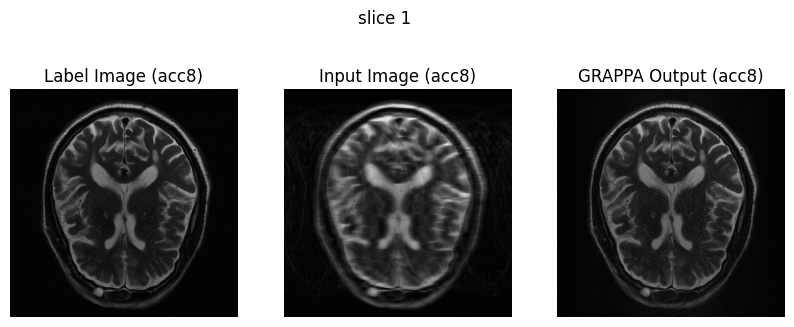

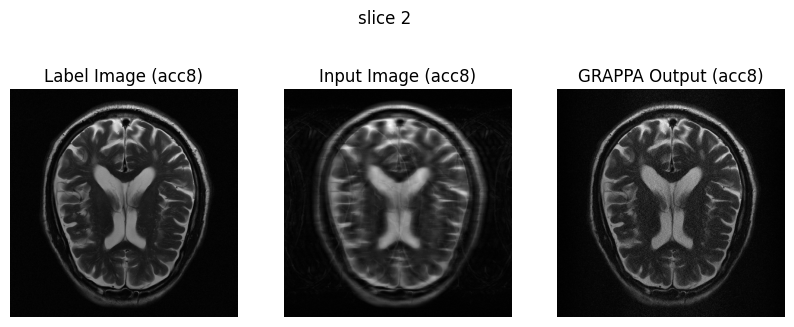

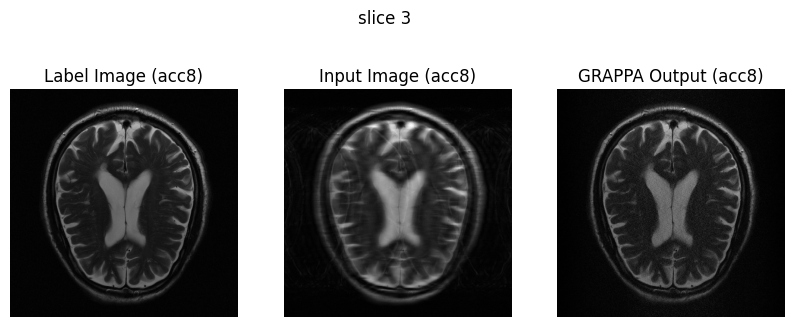

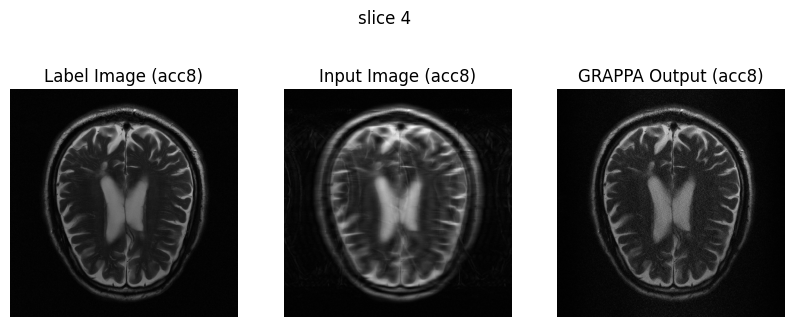

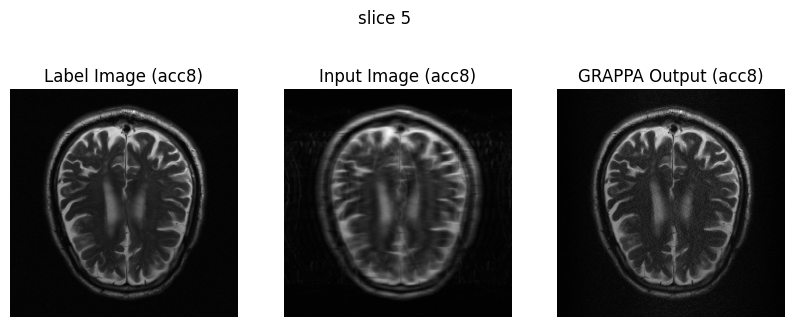

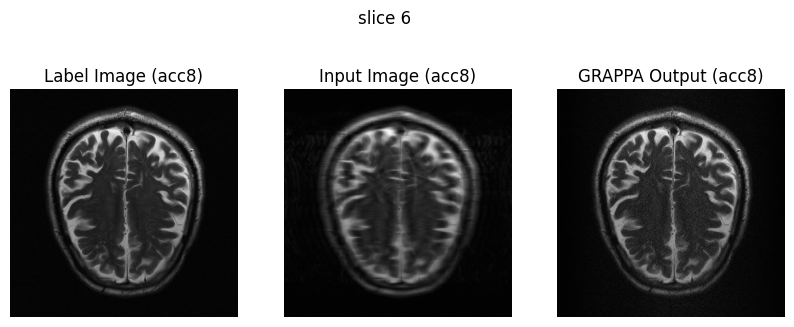

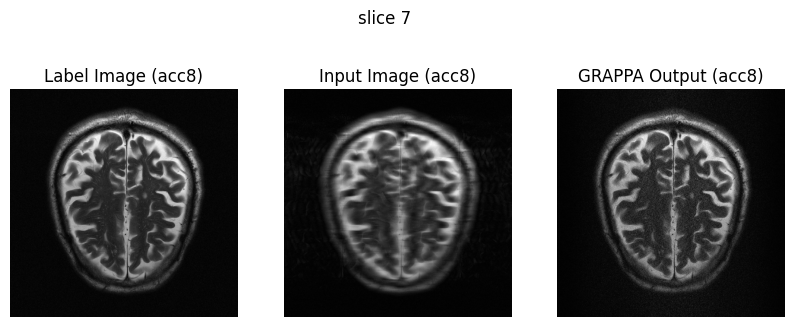

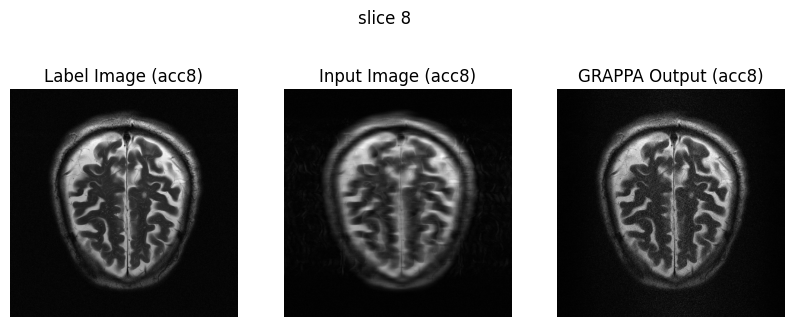

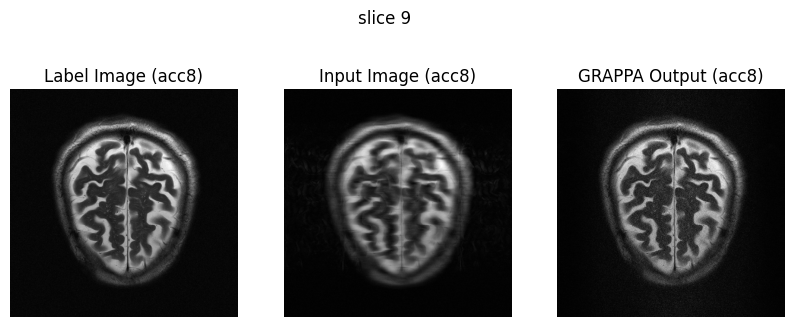

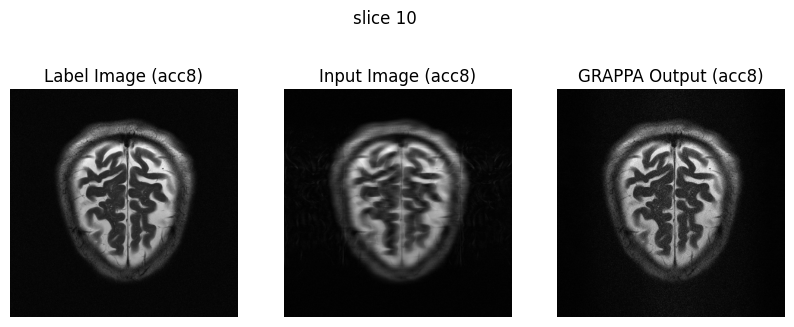

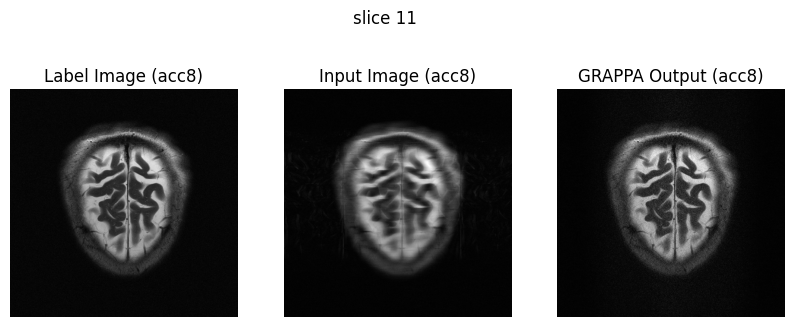

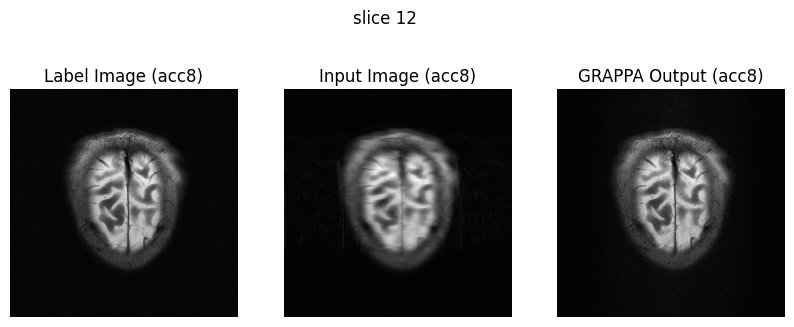

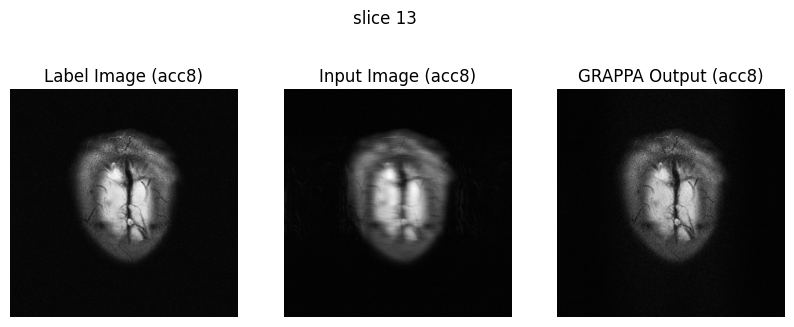

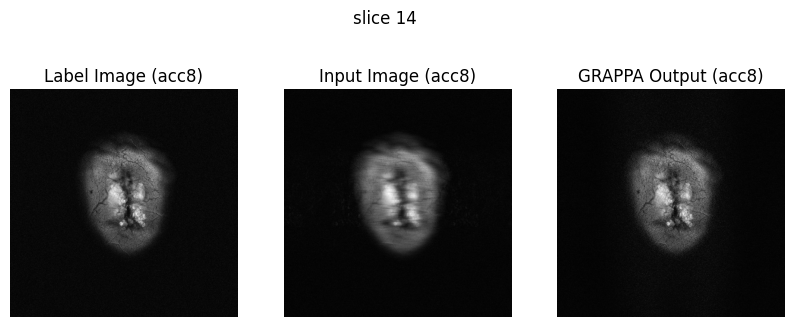

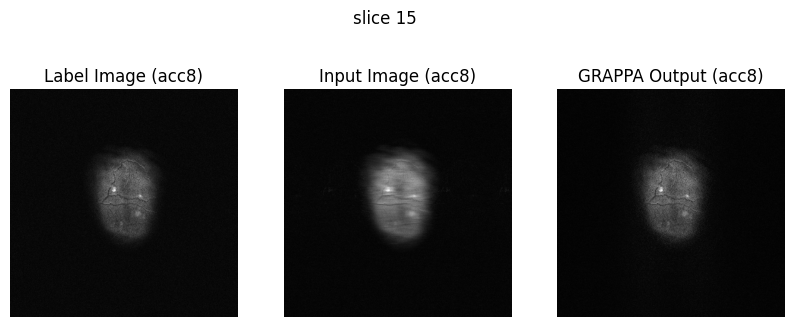

In [13]:
for slice_idx in range(0, image_label.shape[0], 1):
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'slice {slice_idx}')

    ax = plt.subplot(1, 3, 1)
    plt.imshow(image_label[slice_idx], cmap='gray')
    ax.set_title('Label Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 2)
    plt.imshow(image_input[slice_idx], cmap='gray')
    ax.set_title('Input Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 3)
    plt.imshow(image_grappa[slice_idx], cmap='gray')
    ax.set_title('GRAPPA Output')
    ax.axis('off')

    plt.show()

for slice_idx in range(0, image_label_8.shape[0], 1):
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'slice {slice_idx}')

    ax = plt.subplot(1, 3, 1)
    plt.imshow(image_label_8[slice_idx], cmap='gray')
    ax.set_title('Label Image (acc8)')
    ax.axis('off')

    ax = plt.subplot(1, 3, 2)
    plt.imshow(image_input_8[slice_idx], cmap='gray')
    ax.set_title('Input Image (acc8)')
    ax.axis('off')

    ax = plt.subplot(1, 3, 3)
    plt.imshow(image_grappa_8[slice_idx], cmap='gray')
    ax.set_title('GRAPPA Output (acc8)')
    ax.axis('off')

    plt.show()

In [13]:
image_f.close()

## Image data (knee)

knee에 대한 kspace, image data도 brain과 파일 형식, shape 등은 동일합니다.

In [4]:
in_dir = "../Data/train/image/knee_acc4_1.h5"
image_f = h5py.File(in_dir)

image_grappa = image_f['image_grappa']
image_input = image_f['image_input']
image_label = image_f['image_label']

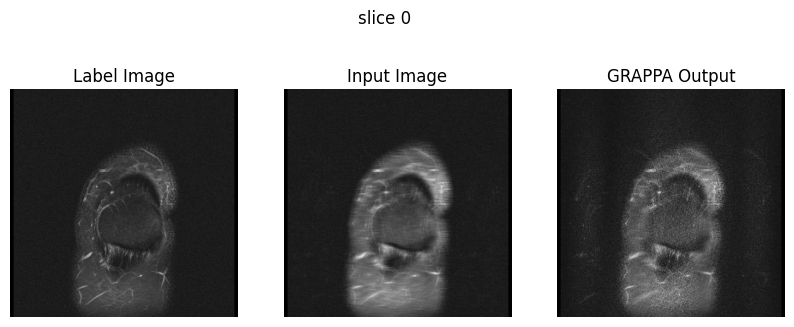

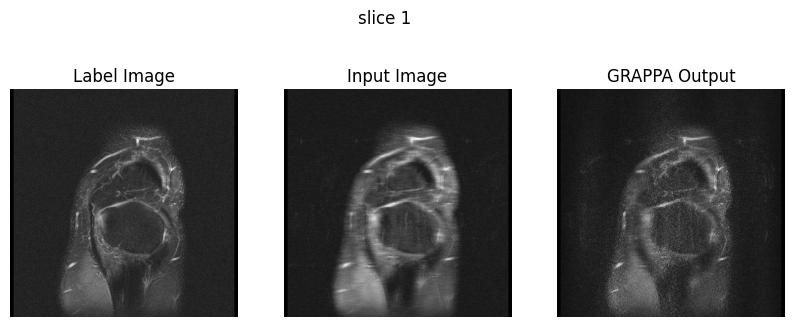

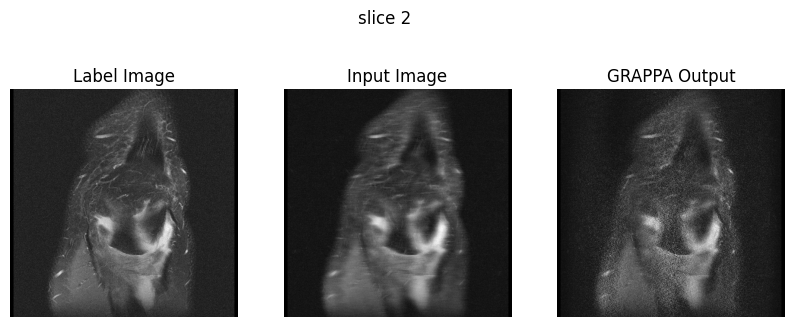

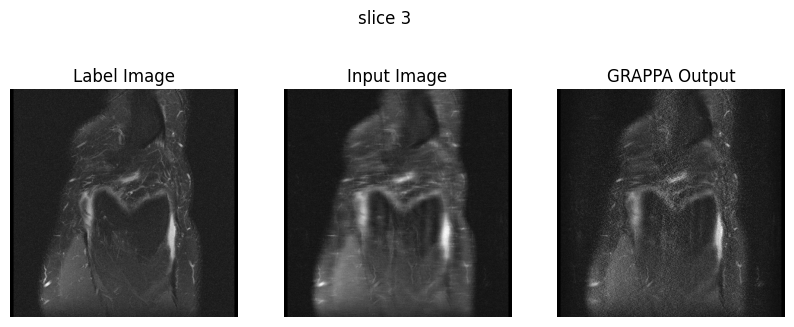

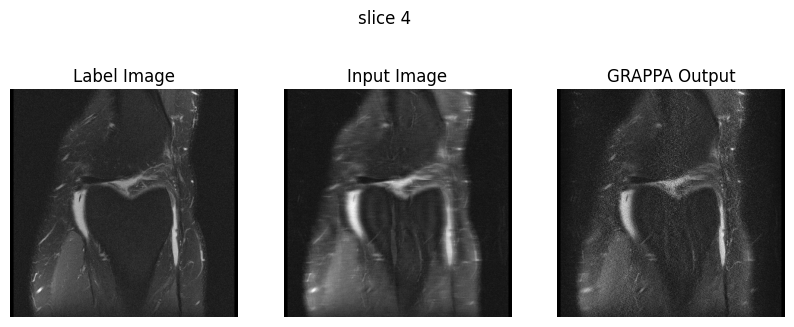

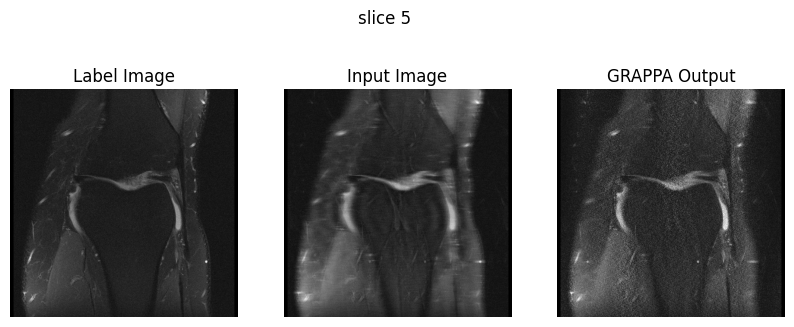

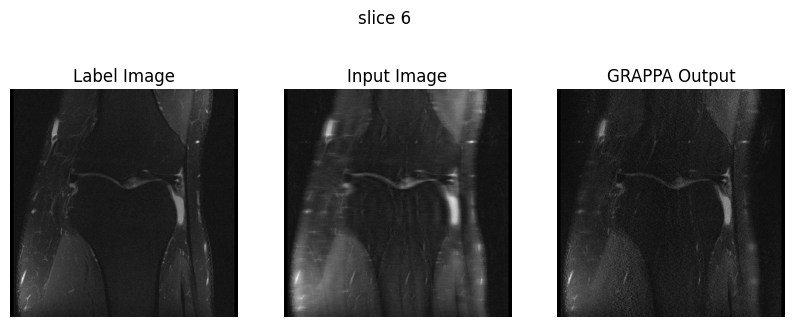

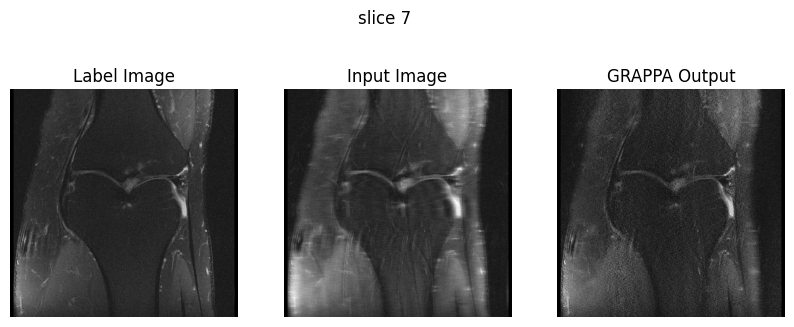

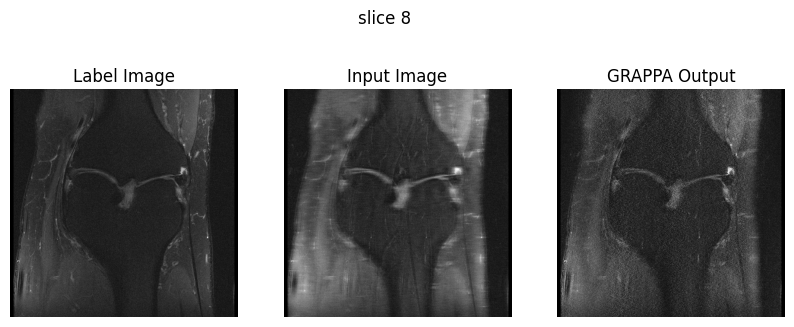

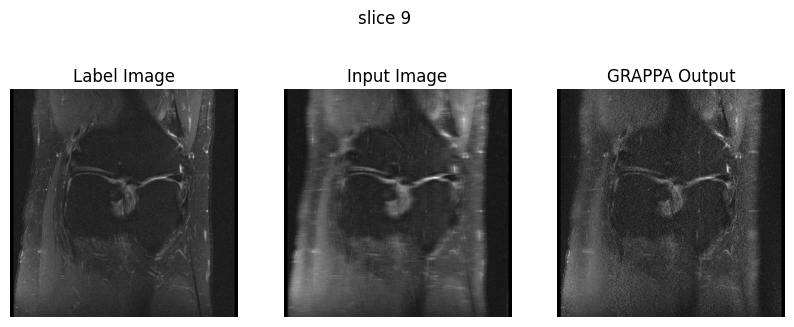

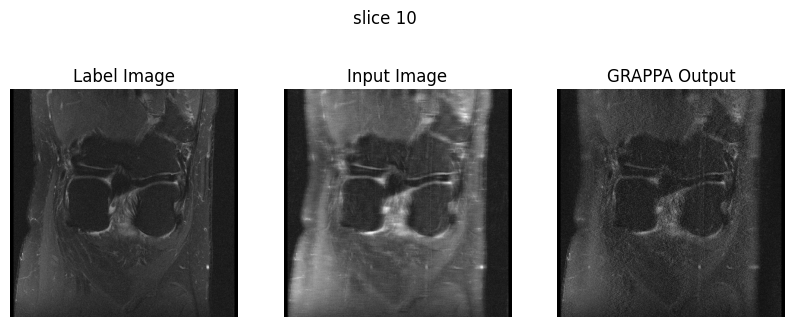

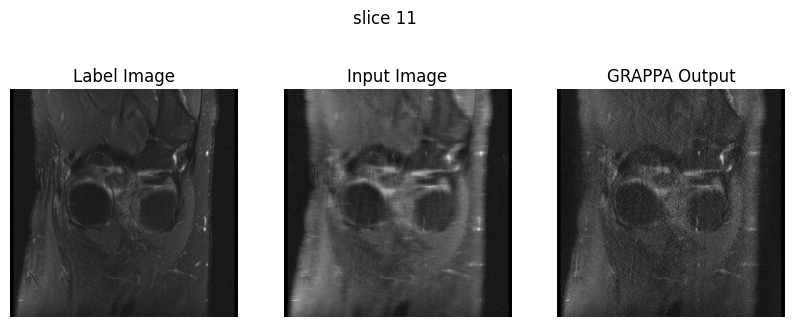

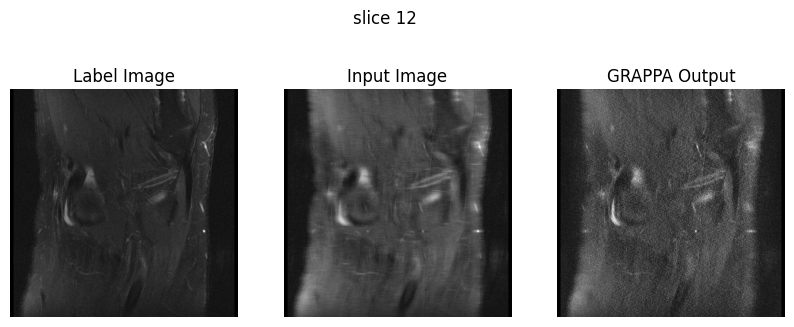

In [6]:
for slice_idx in range(0, image_label.shape[0], 1):
    plt.figure(figsize=(10, 4))
    plt.suptitle(f'slice {slice_idx}')

    ax = plt.subplot(1, 3, 1)
    plt.imshow(image_label[slice_idx], cmap='gray')
    ax.set_title('Label Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 2)
    plt.imshow(image_input[slice_idx], cmap='gray')
    ax.set_title('Input Image')
    ax.axis('off')

    ax = plt.subplot(1, 3, 3)
    plt.imshow(image_grappa[slice_idx], cmap='gray')
    ax.set_title('GRAPPA Output')
    ax.axis('off')

    plt.show()

In [17]:
image_f.close()

In [3]:
in_dir = "../Data/train/image/brain_acc4_1.h5"
image_f = h5py.File(in_dir)
image_grappa = image_f['image_grappa']
image_input = image_f['image_input']
image_label = image_f['image_label']

in_dir = "../Data/train/kspace/brain_acc4_1.h5"
kspace_f = h5py.File(in_dir)
kspace = kspace_f['kspace']
mask = kspace_f['mask']

kspace_slice shape: torch.Size([1, 16, 768, 396, 2])
result shape: torch.Size([384, 384])


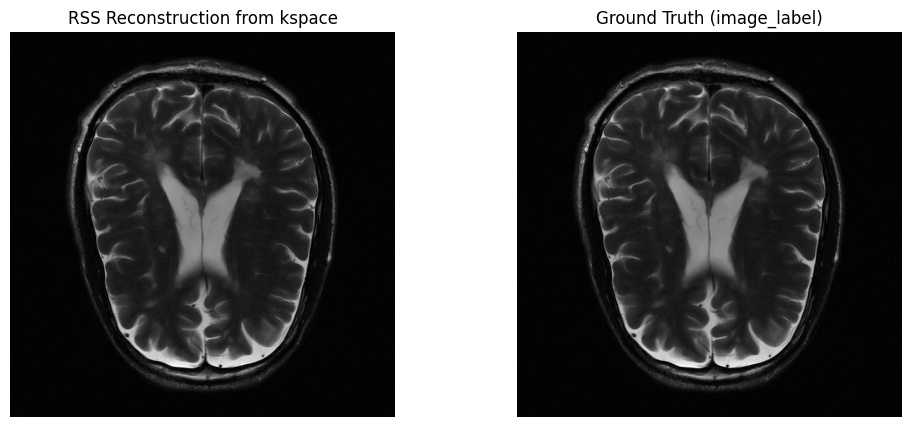

tensor(1.3304e-05) 1.3303962e-05
mean squared error: tensor(7.3409e-23)
type of result: <class 'torch.Tensor'> type of label_img: <class 'numpy.ndarray'>


C:\Users\user\AppData\Local\Temp\ipykernel_21244\1385010142.py:117: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  print('mean squared error:', ((result - label_img) ** 2).mean())


SSIM value: 1.0


In [5]:
import torch
import torch.nn.functional as F
from utils.common.utils import center_crop
from utils.common.loss_function import SSIMLoss
from typing import List, Optional

def rss(data: torch.Tensor, dim: int = 0) -> torch.Tensor:
    return torch.sqrt((data ** 2).sum(dim))

def complex_abs(data: torch.Tensor) -> torch.Tensor:
    if not data.shape[-1] == 2:
        raise ValueError("Tensor does not have separate complex dim.")

    return (data ** 2).sum(dim=-1).sqrt()

def roll_one_dim(x: torch.Tensor, shift: int, dim: int) -> torch.Tensor:
    shift = shift % x.size(dim)
    if shift == 0:
        return x

    left = x.narrow(dim, 0, x.size(dim) - shift)
    right = x.narrow(dim, x.size(dim) - shift, shift)

    return torch.cat((right, left), dim=dim)

def roll(
    x: torch.Tensor,
    shift: List[int],
    dim: List[int],
) -> torch.Tensor:
    if len(shift) != len(dim):
        raise ValueError("len(shift) must match len(dim)")

    for (s, d) in zip(shift, dim):
        x = roll_one_dim(x, s, d)

    return x

def fftshift(x: torch.Tensor, dim: Optional[List[int]] = None) -> torch.Tensor:
    if dim is None:
        # this weird code is necessary for toch.jit.script typing
        dim = [0] * (x.dim())
        for i in range(1, x.dim()):
            dim[i] = i

    # also necessary for torch.jit.script
    shift = [0] * len(dim)
    for i, dim_num in enumerate(dim):
        shift[i] = x.shape[dim_num] // 2

    return roll(x, shift, dim)

def ifftshift(x: torch.Tensor, dim: Optional[List[int]] = None) -> torch.Tensor:
    if dim is None:
        # this weird code is necessary for toch.jit.script typing
        dim = [0] * (x.dim())
        for i in range(1, x.dim()):
            dim[i] = i

    # also necessary for torch.jit.script
    shift = [0] * len(dim)
    for i, dim_num in enumerate(dim):
        shift[i] = (x.shape[dim_num] + 1) // 2

    return roll(x, shift, dim)

def ifft2c_new(data: torch.Tensor, norm: str = "ortho") -> torch.Tensor:
    if not data.shape[-1] == 2:
        raise ValueError("Tensor does not have separate complex dim.")

    data = ifftshift(data, dim=[-3, -2])
    data = torch.view_as_real(
        torch.fft.ifftn(  # type: ignore
            torch.view_as_complex(data), dim=(-2, -1), norm=norm
        )
    )
    data = fftshift(data, dim=[-3, -2])

    return data

# 한 slice에 대해 각 coil별 kspace 데이터를 ifft 후 RSS 계산 및 image_label과 비교
slice_idx = 0  # 비교할 slice index

slice_data = kspace[slice_idx]
if isinstance(slice_data, torch.Tensor):
    slice_data = slice_data.cpu().numpy()
else:
    slice_data = np.array(slice_data)

slice_data = np.stack([slice_data.real, slice_data.imag], axis=-1)  # (coil, height, width, 2)
kspace_slice = torch.from_numpy(slice_data).float().unsqueeze(0)    # (1, coil, height, width, 2)
print("kspace_slice shape:", kspace_slice.shape)

result = rss(complex_abs(ifft2c_new(kspace_slice)), dim=1)
result = center_crop(result, 384, 384)
result = result.squeeze(0).cpu()  # (height, width)
print("result shape:", result.shape)  # (height, width)

# image_label shape: (slice, height, width)
label_img = image_label[slice_idx]

# 시각화
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.imshow(result, cmap='gray')
plt.title('RSS Reconstruction from kspace')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(label_img, cmap='gray')
plt.title('Ground Truth (image_label)')
plt.axis('off')

plt.show()

print(result[0, 0], label_img[0, 0])  # 첫 픽셀 값 비교
print('mean squared error:', ((result - label_img) ** 2).mean())
class SSIM(SSIMLoss):
    def __init__(self, win_size: int = 7, k1: float = 0.01, k2: float = 0.03):
        super().__init__(win_size, k1, k2)
            
    def forward(self, X, Y, data_range):
        if len(X.shape) != 2:
            raise NotImplementedError('Dimension of first input is {} rather than 2'.format(len(X.shape)))
        if len(Y.shape) != 2:
            raise NotImplementedError('Dimension of first input is {} rather than 2'.format(len(Y.shape)))
        
        X = X.unsqueeze(0).unsqueeze(0)
        Y = Y.unsqueeze(0).unsqueeze(0)
        w = self.w.to(X.device)  # weight를 복사본으로 사용
        C1 = (self.k1 * data_range) ** 2
        C2 = (self.k2 * data_range) ** 2
        ux = F.conv2d(X, w)
        uy = F.conv2d(Y, w)
        uxx = F.conv2d(X * X, w)
        uyy = F.conv2d(Y * Y, w)
        uxy = F.conv2d(X * Y, w)
        vx = self.cov_norm * (uxx - ux * ux)
        vy = self.cov_norm * (uyy - uy * uy)
        vxy = self.cov_norm * (uxy - ux * uy)
        A1, A2, B1, B2 = (
            2 * ux * uy + C1,
            2 * vxy + C2,
            ux ** 2 + uy ** 2 + C1,
            vx + vy + C2,
        )
        D = B1 * B2
        S = (A1 * A2) / D
        return S.mean()
# SSIM 계산
ssim_loss = SSIM()
device = torch.device(f'cuda:{0}' if torch.cuda.is_available() else 'cpu')
torch.cuda.set_device(device)
print('type of result:', type(result), 'type of label_img:', type(label_img))
label_img = torch.from_numpy(label_img).float().to(device=device)
result = result.float().to(device=device)
ssim_value = ssim_loss(result, label_img, data_range=1.0)
print("SSIM value:", ssim_value.item())

In [19]:
kspace_np = np.array(kspace)
kspace_np = np.stack([kspace_np.real, kspace_np.imag], axis=-1)
kspace_np = torch.tensor(kspace_np, dtype=torch.float32)
print("kspace_np shape:", kspace_np.shape)  # (slice, coil, height, width, 2)
result = rss(complex_abs(ifft2c_new(kspace_np)), dim=1)
print("result shape:", result.shape)  # (height, width)

kspace_np shape: torch.Size([16, 16, 768, 396, 2])
result shape: torch.Size([16, 768, 396])


In [31]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.backends.backend_pdf import PdfPages

# 파일 경로 리스트 생성
base_path = Path('../Data/leaderboard/acc8/image')
file_list = [base_path / f'knee_test{i}.h5' for i in range(1, 29)]

# 각 파일에서 slice 1, 5의 label 이미지 추출
images = []
indices = []
for n, f in enumerate(file_list, start=1):
    with h5py.File(f, 'r') as hf:
        label = hf['image_label']
        # images.append(label[0])
        images.append(label[int(len(label)/3)])
        images.append(label[int(len(label)*2/3)])
        images.append(label[int(len(label)-1)])
        # indices.append([n, 0])
        indices.append([n, int(len(label)/3)])
        indices.append([n, int(len(label)*2/3)])
        indices.append([n, int(len(label)-1)])

# 이제 images에는 총 15*2 = 30개 이미지가 들어 있음

# 15개씩 잘라 페이지 단위로 묶기
chunks = [images[i:i+15] for i in range(0, len(images), 15)]
indices_chunks = [indices[i:i+15] for i in range(0, len(indices), 15)]

pdf_path = 'brain_label_grid_a4_1.pdf'


with PdfPages(pdf_path) as pdf:
    for page_idx, chunk in enumerate(chunks, start=1):
        indices_chunk = indices_chunks[page_idx - 1] 
        fig, axes = plt.subplots(5, 3, figsize=(8.3, 11.7))  # A4 landscape
        for idx, ax in enumerate(axes.flat):
            if idx < len(chunk):
                # slice 번호 계산: 파일 번호 = idx//2 + 1, slice 번호 = 1 혹은 5
                file_num = indices_chunk[idx][0]
                slice_num = indices_chunk[idx][1]
                ax.imshow(chunk[idx], cmap='gray')
                ax.set_title(f'File {file_num} Slice {slice_num}')
            ax.axis('off')
        plt.tight_layout()
        pdf.savefig(fig)
        plt.close(fig)

print(f'PDF saved to {pdf_path}')


PDF saved to brain_label_grid_a4_1.pdf
